
# Dynamic Programming (DP) — Policy Evaluation, Policy Iteration, Value Iteration

**Updated:** 2025-08-24 (UTC)

This notebook reproduces and adapts the core code from **Hands-on RL — Chapter 4: Dynamic Programming**  
(Cliff Walking environment, Policy Iteration, Value Iteration) with **English comments**.

**Source & License**  
- Original tutorial page: *Hands-on RL — Chapter 4 (Dynamic Programming)*.  
- Official repository: `boyu-ai/Hands-on-RL` (Apache-2.0 License).  
Code here is adapted under the Apache-2.0 license with attribution.


## 1. Imports & Print Settings

In [1]:

import copy
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)



## 2. Cliff Walking Environment (4×12 Grid)

This environment mirrors the one used in the tutorial:

- Grid size: 4 rows × 12 columns (index origin at top-left in our code comments)
- Start: bottom-left cell
- Goal: bottom-right cell
- Actions: up, down, left, right (4 actions)
- Reward: `-1` per step; `-100` if you step into the cliff; `0` at the goal
- Episode ends when you step into the cliff **or** reach the goal; those states are terminal/absorbing

We build a transition table `P[state][action] -> list[(prob, next_state, reward, done)]`.


In [2]:

class CliffWalkingEnv:
    """Cliff Walking environment (deterministic) adapted from Hands-on RL Ch.4.

    State indexing:
      - States are flattened: state_id = row * ncol + col
      - Rows: 0..nrow-1 (top to bottom), Cols: 0..ncol-1 (left to right)

    Terminal states:
      - Entire bottom row except the leftmost cell (start) is terminal:
          * cliff cells: (row == nrow-1, col in 1..ncol-2) -> reward = -100, done = True
          * goal cell:  (row == nrow-1, col == ncol-1)     -> reward = 0, done = True
      - When you're already in any terminal, any action keeps you there with reward 0.
    """
    def __init__(self, ncol: int = 12, nrow: int = 4):
        self.ncol = int(ncol)  # number of columns
        self.nrow = int(nrow)  # number of rows
        # Transition table: P[state][action] = [(p, next_state, reward, done)]
        self.P = self._create_P()

    def _create_P(self):
        # Initialize empty transition table
        P = [[[] for _ in range(4)] for _ in range(self.nrow * self.ncol)]
        # Action deltas: 0:up, 1:down, 2:left, 3:right (dx, dy)
        #   NOTE: (x,y) increases to the right/down.
        change = [[0, -1],  # up    -> y-1
                  [0,  1],  # down  -> y+1
                  [-1, 0],  # left  -> x-1
                  [1,  0]]  # right -> x+1

        for i in range(self.nrow):        # row index
            for j in range(self.ncol):    # col index
                s = i * self.ncol + j
                for a in range(4):
                    # If at cliff/goal (bottom row except col=0), stay with reward 0 and done=True
                    if i == self.nrow - 1 and j > 0:
                        P[s][a] = [(1.0, s, 0.0, True)]
                        continue

                    # Otherwise, try to move according to action, but clamp to grid bounds
                    next_x = min(self.ncol - 1, max(0, j + change[a][0]))
                    next_y = min(self.nrow - 1, max(0, i + change[a][1]))
                    next_state = next_y * self.ncol + next_x

                    # Default step reward and termination
                    reward = -1.0
                    done = False

                    # If the *next* state is on bottom row (and not the leftmost start cell),
                    # it's terminal. If it's the goal (last column), reward stays 0;
                    # otherwise it's a cliff with reward -100.
                    if next_y == self.nrow - 1 and next_x > 0:
                        done = True
                        if next_x != self.ncol - 1:   # cliff
                            reward = -100.0
                        else:                         # goal
                            reward = 0.0

                    P[s][a] = [(1.0, next_state, reward, done)]
        return P



## 3. Policy Iteration

Policy Iteration alternates between:
1) **Policy Evaluation**: compute the state-value function \(V^{\pi}\) of the current policy \(\pi\)  
2) **Policy Improvement**: update \(\pi\) to be greedy w.r.t. \(V^{\pi}\)

We implement it in a class mirroring the tutorial's structure.


In [3]:

class PolicyIteration:
    """Policy Iteration (synchronous, tabular) adapted from Hands-on RL Ch.4."""
    def __init__(self, env: CliffWalkingEnv, theta: float = 1e-6, gamma: float = 0.9):
        self.env = env
        # Value function V(s), initialized to 0
        self.v = [0.0] * (self.env.nrow * self.env.ncol)
        # Stochastic policy π(s) over 4 actions, start as uniform
        self.pi = [[0.25, 0.25, 0.25, 0.25] for _ in range(self.env.nrow * self.env.ncol)]
        self.theta = float(theta)  # evaluation convergence threshold
        self.gamma = float(gamma)  # discount factor

    def policy_evaluation(self):
        """Iterative policy evaluation for the current policy self.pi."""
        cnt = 1  # iteration counter (for logging)
        while True:
            max_diff = 0.0
            new_v = [0.0] * (self.env.nrow * self.env.ncol)

            for s in range(self.env.nrow * self.env.ncol):
                qsa_sum = 0.0  # sum_a π(a|s) * Q(s,a)
                for a in range(4):
                    qsa = 0.0
                    # Sum over outcomes: here deterministic, so only one (p, s', r, done)
                    for (p, next_state, r, done) in self.env.P[s][a]:
                        # In this chapter, rewards depend on next_state, so we multiply by p as well
                        qsa += p * (r + self.gamma * self.v[next_state] * (1 - int(done)))
                    qsa_sum += self.pi[s][a] * qsa

                new_v[s] = qsa_sum
                max_diff = max(max_diff, abs(new_v[s] - self.v[s]))

            self.v = new_v
            if max_diff < self.theta:
                break
            cnt += 1
        print(f"Policy evaluation finished after {cnt} iteration(s).")

    def policy_improvement(self):
        """Improve policy greedily w.r.t. current value function self.v."""
        for s in range(self.env.nrow * self.env.ncol):
            qsa_list = []
            for a in range(4):
                qsa = 0.0
                for (p, next_state, r, done) in self.env.P[s][a]:
                    qsa += p * (r + self.gamma * self.v[next_state] * (1 - int(done)))
                qsa_list.append(qsa)

            max_q = max(qsa_list)
            # Count how many actions achieve the same max Q, and split prob equally among them
            count_max = qsa_list.count(max_q)
            self.pi[s] = [1.0 / count_max if q == max_q else 0.0 for q in qsa_list]

        print("Policy improvement completed.")
        return self.pi

    def policy_iteration(self):
        """Run policy iteration until policy is stable."""
        while True:
            self.policy_evaluation()
            old_pi = copy.deepcopy(self.pi)
            new_pi = self.policy_improvement()
            if old_pi == new_pi:  # stable
                break
        return self.pi, self.v



## 4. Value Iteration

Value Iteration applies **Bellman optimality** updates directly to \(V\).  
After convergence, extract the greedy policy.


In [4]:

class ValueIteration:
    """Value Iteration (synchronous, tabular) adapted from Hands-on RL Ch.4."""
    def __init__(self, env: CliffWalkingEnv, theta: float = 1e-6, gamma: float = 0.9):
        self.env = env
        self.v = [0.0] * (self.env.nrow * self.env.ncol)
        self.gamma = float(gamma)
        self.theta = float(theta)

    def iterate(self):
        deltas = []
        it = 0
        while True:
            it += 1
            max_diff = 0.0
            new_v = [0.0] * (self.env.nrow * self.env.ncol)

            for s in range(self.env.nrow * self.env.ncol):
                # terminal states have value 0 by construction (absorbing with reward 0)
                # but the update below also handles them correctly via env.P
                q_values = []
                for a in range(4):
                    qsa = 0.0
                    for (p, next_state, r, done) in self.env.P[s][a]:
                        qsa += p * (r + self.gamma * self.v[next_state] * (1 - int(done)))
                    q_values.append(qsa)
                new_v[s] = max(q_values)
                max_diff = max(max_diff, abs(new_v[s] - self.v[s]))

            self.v = new_v
            deltas.append(max_diff)
            if max_diff < self.theta:
                break
        return deltas

    def greedy_policy(self):
        """Extract a greedy deterministic policy from the current value function."""
        pi = []
        for s in range(self.env.nrow * self.env.ncol):
            q_values = []
            for a in range(4):
                qsa = 0.0
                for (p, next_state, r, done) in self.env.P[s][a]:
                    qsa += p * (r + self.gamma * self.v[next_state] * (1 - int(done)))
                q_values.append(qsa)
            # Choose the smallest index if ties
            best_a = int(np.argmax(q_values))
            det = [0.0, 0.0, 0.0, 0.0]
            det[best_a] = 1.0
            pi.append(det)
        return pi



## 5. Utilities: Pretty-print Values & Policies


In [5]:

def print_values(agent_or_values, nrow: int, ncol: int, title: str = "State Values"):
    """Print a value table in grid form."""
    if hasattr(agent_or_values, "v"):
        v = agent_or_values.v
    else:
        v = agent_or_values
    print(title)
    for i in range(nrow):
        row_vals = []
        for j in range(ncol):
            row_vals.append(f"{v[i*ncol + j]:6.2f}")
        print(" ".join(row_vals))
    print()

def print_policy(pi, nrow: int, ncol: int, title: str = "Policy"):
    """Print a deterministic/stochastic policy.
    - If pi is a list of lists (length 4): treat as stochastic over [up, down, left, right].
    - We render the greedy direction; if ties exist, we list all best arrows.
    """
    arrow = {0:"^", 1:"v", 2:"<", 3:">"}  # order aligned with env actions in this notebook
    print(title)
    for i in range(nrow):
        row_syms = []
        for j in range(ncol):
            s = i*ncol + j
            p = pi[s]
            # Determine best action(s)
            if isinstance(p, list) and len(p) == 4:
                best = np.argwhere(np.array(p) == np.max(p)).flatten().tolist()
            elif isinstance(p, int):
                best = [p]
            else:
                # fallback: greedy over provided vector/array
                arr = np.array(p, dtype=float).ravel()
                best = np.argwhere(arr == np.max(arr)).flatten().tolist()
            # Special case: terminals on bottom row except j==0
            if i == nrow-1 and j > 0:
                row_syms.append("T")
            else:
                row_syms.append("".join(arrow[a] for a in best))
        print(" ".join(sym if sym else "." for sym in row_syms))
    print()



## 6. Demo: Run Policy Iteration & Value Iteration


Policy evaluation finished after 135 iteration(s).
Policy improvement completed.
Policy evaluation finished after 182 iteration(s).
Policy improvement completed.
Policy evaluation finished after 142 iteration(s).
Policy improvement completed.
Policy evaluation finished after 12 iteration(s).
Policy improvement completed.
Policy evaluation finished after 1 iteration(s).
Policy improvement completed.
V* from Policy Iteration
 -7.46  -7.18  -6.86  -6.51  -6.13  -5.70  -5.22  -4.69  -4.10  -3.44  -2.71  -1.90
 -7.18  -6.86  -6.51  -6.13  -5.70  -5.22  -4.69  -4.10  -3.44  -2.71  -1.90  -1.00
 -6.86  -6.51  -6.13  -5.70  -5.22  -4.69  -4.10  -3.44  -2.71  -1.90  -1.00   0.00
 -7.18   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00

π* from Policy Iteration (greedy, ties shown)
v> v> v> v> v> v> v> v> v> v> v> v
v> v> v> v> v> v> v> v> v> v> v> v
> > > > > > > > > > > v
^ T T T T T T T T T T T

V* from Value Iteration
 -7.46  -7.18  -6.86  -6.51  -6.13  -5.70  -5.2

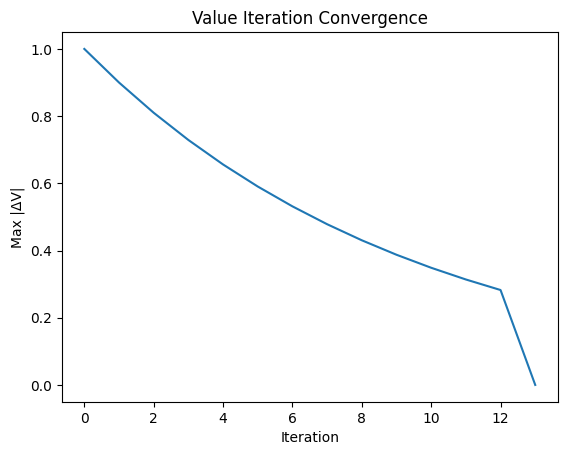

In [6]:

# Build environment
env = CliffWalkingEnv(ncol=12, nrow=4)

# --- Policy Iteration ---
pi_agent = PolicyIteration(env, theta=1e-8, gamma=0.9)
pi_agent.policy_iteration()
print_values(pi_agent, env.nrow, env.ncol, title="V* from Policy Iteration")
print_policy(pi_agent.pi, env.nrow, env.ncol, title="π* from Policy Iteration (greedy, ties shown)")

# --- Value Iteration ---
vi_agent = ValueIteration(env, theta=1e-8, gamma=0.9)
deltas = vi_agent.iterate()
pi_vi = vi_agent.greedy_policy()
print_values(vi_agent, env.nrow, env.ncol, title="V* from Value Iteration")
print_policy(pi_vi, env.nrow, env.ncol, title="π* from Value Iteration (greedy)")

# Convergence plot for VI
plt.figure()
plt.plot(deltas)
plt.xlabel("Iteration")
plt.ylabel("Max |ΔV|")
plt.title("Value Iteration Convergence")
plt.show()
